In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize

In [2]:
xls = pd.ExcelFile('data/srcsc-2026-claims-workers-comp.xlsx')
xls.sheet_names

['freq', 'sev']

In [3]:
df_workers_freq = pd.read_excel(xls, 'freq')
df_workers_sev = pd.read_excel(xls, 'sev')

In [4]:
df_workers_freq.head()

,policy_id,worker_id,solar_system,station_id,occupation,employment_type,experience_yrs,accident_history_flag,psych_stress_index,hours_per_week,supervision_level,gravity_level,safety_training_index,protective_gear_quality,base_salary,exposure,claim_count
0,WC-EPS-00001,W-00001,Epsilon,B7,Scientist,Full-time,20.59,0.0,3.0,40.0,0.4,0.829,5.0,2.0,69646.0,0.943,0.0
1,WC-EPS-00001,W-00002,Epsilon,A8,Administrator,Contract,10.26,0.0,1.0,30.0,0.5,0.991,5.0,4.0,46501.0,0.293,0.0
2,WC-EPS-00001,W-00003,Epsilon,A7,Planetary Operations,Full-time,10.58,0.0,1.0,40.0,0.1,0.873,5.0,5.0,40640.0,0.888,0.0
3,WC-EPS-00001,W-00004,Epsilon,G1,Planetary Operations,Contract,9.03,0.0,1.0,20.0,0.4,0.976,5.0,2.0,46031.0,0.213,0.0
4,WC-EPS-00001,W-00005,Epsilon,A8,Drill Operator,Full-time,6.76,0.0,1.0,30.0,0.2,0.752,5.0,2.0,39244.0,0.158,0.0


In [5]:
df_workers_sev.head()

,claim_id,claim_seq,policy_id,worker_id,solar_system,station_id,occupation,employment_type,experience_yrs,accident_history_flag,...,supervision_level,gravity_level,safety_training_index,protective_gear_quality,base_salary,exposure,injury_type,injury_cause,claim_length,claim_amount
0,C-0000001,1.0,WC-EPS-00003,W-00078,Epsilon,B2,Engineer,Full-time,14.43,0.0,...,0.5,0.812,5.0,3,69264.0,0.514,Cut laceration,Exposure,9.0,1624.23
1,C-0000002,1.0,WC-HEL-00001,W-00137,Helionis Cluster,G2,Manager,Full-time,22.00,0.0,...,0.2,1.068,3.0,3,71782.0,0.483,"Sprain, strain",Vehicle accident,7.0,5528.05
2,C-0000003,1.0,WC-EPS-00005,W-00413,Epsilon,B4,Maintenance Staff,Contract,7.40,0.0,...,0.1,0.944,3.0,5,30000.0,0.355,Cut laceration,Stress/strain,6.0,2095.00
3,C-0000004,2.0,WC-EPS-00005,W-00413,Epsilon,B4,Maintenance Staff,Contract,7.40,0.0,...,0.1,0.944,3.0,5,30000.0,0.355,"Sprain, strain",Overexertion,6.0,765.96
4,C-0000005,1.0,WC-EPS-00005,W-00477,Epsilon,G9,Drill Operator,Full-time,8.37,0.0,...,0.3,0.832,5.0,5,40624.0,0.863,Psychological,Stress/strain,4.0,4025.63


In [6]:
common_cols = df_workers_freq.columns.intersection(df_workers_sev.columns).tolist()
print("Common columns:", common_cols)
uncommon_cols_freq = df_workers_freq.columns.difference(df_workers_sev.columns).tolist()
print("Uncommon columns in freq:", uncommon_cols_freq)
uncommon_cols_sev = df_workers_sev.columns.difference(df_workers_freq.columns).tolist()
print("Uncommon columns in sev:", uncommon_cols_sev)

Common columns: ['policy_id', 'worker_id', 'solar_system', 'station_id', 'occupation', 'employment_type', 'experience_yrs', 'accident_history_flag', 'psych_stress_index', 'hours_per_week', 'supervision_level', 'gravity_level', 'safety_training_index', 'protective_gear_quality', 'base_salary', 'exposure']
Uncommon columns in freq: ['claim_count']
Uncommon columns in sev: ['claim_amount', 'claim_id', 'claim_length', 'claim_seq', 'injury_cause', 'injury_type']


In [7]:
df = df_workers_freq.copy()
df.describe()

,experience_yrs,accident_history_flag,psych_stress_index,hours_per_week,supervision_level,gravity_level,safety_training_index,protective_gear_quality,base_salary,exposure,claim_count
count,134844.000000,134846.000000,134864.000000,134849.000000,134858.000000,134840.000000,134850.000000,134844.000000,1.348460e+05,134852.000000,134859.000000
mean,11.789641,0.102215,2.021361,35.259602,0.288218,1.125188,4.027471,3.834295,5.003486e+04,0.504322,0.014269
std,7.376239,0.325868,1.510258,12.827819,0.201076,0.404565,1.894290,1.970503,2.246774e+04,0.290236,0.123596
min,-25.960000,-1.000000,-5.000000,-40.000000,-0.600000,-1.499000,-5.000000,-5.000000,-9.603500e+04,-0.910000,0.000000
25%,7.510000,0.000000,1.000000,30.000000,0.200000,0.903000,3.000000,3.000000,3.917800e+04,0.326000,0.000000
50%,9.630000,0.000000,2.000000,40.000000,0.300000,1.113000,4.000000,4.000000,4.319800e+04,0.500000,0.000000
75%,15.510000,0.000000,3.000000,40.000000,0.400000,1.340000,5.000000,5.000000,6.007700e+04,0.673000,0.000000
max,453.279025,19.318454,92.522795,786.719599,10.249869,27.470280,98.223135,97.766900,1.316479e+06,16.699989,11.248512


In [11]:
def initial_cleaning(df):
    df = df.copy()

    print(df.info())
    print(df.shape)

    cat_cols = df.select_dtypes(include=["object", "str", "category"]).columns
    print("Categorical columns:", cat_cols)
    num_cols = df.select_dtypes(include=["number"]).columns
    print("Numerical columns:", num_cols)

    null_rows = df[df.isnull().any(axis=1)]
    null_pct = (len(null_rows) / len(df)) * 100
    print(f"Percentage of rows with null values: {null_pct:.2f}%")
    if null_pct < 5:
        df = df.dropna()
        print("Shape after dropping nulls:", df.shape)

    unique_cols = ["solar_system", "occupation", "employment_type"]
    for col in unique_cols:
        print(df[col].unique())
        df[col] = df[col].str.extract(r"^([A-Za-z\s]+)")
        print(df[col].unique())

    # Clean categorical columns in sev sheet
    if "injury_type" in df.columns and "injury_cause" in df.columns:
        print(
            f"\nUnique values in 'injury_type' (before): {df['injury_type'].unique()}"
        )
        df["injury_type"] = df["injury_type"].str.extract(r"^([A-Za-z\s]+)")
        print(f"Unique values in 'injury_type' (after): {df['injury_type'].unique()}")

    # Ranges: claim_count 0-2,
    # exposure 0-1, accident_history_flag 0-1, experience_yrs <=40,
    # psych_stress_index 1-5, hours_per_week 20-40, supervision_level 0-1,
    # gravity_level 0.75-1.5, safety_training_index 1-5, protective_gear_quality 1-5
    df_filtered = df[
        (df["exposure"] >= 0)
        & (df["exposure"] <= 1)
        & (df["accident_history_flag"] >= 0)
        & (df["accident_history_flag"] <= 1)
        & (df["experience_yrs"] >= 0)
        & (df["experience_yrs"] <= 40)
        & (df["psych_stress_index"] >= 1)
        & (df["psych_stress_index"] <= 5)
        & (df["hours_per_week"] >= 20)
        & (df["hours_per_week"] <= 40)
        & (df["supervision_level"] >= 0)
        & (df["supervision_level"] <= 1)
        & (df["gravity_level"] >= 0.75)
        & (df["gravity_level"] <= 1.5)
        & (df["safety_training_index"] >= 1)
        & (df["safety_training_index"] <= 5)
        & (df["protective_gear_quality"] >= 1)
        & (df["protective_gear_quality"] <= 5)
    ]
    if 'claim_count' in df_filtered.columns:
        df_filtered = df_filtered[
            (df_filtered["claim_count"] >= 0) & (df_filtered["claim_count"] <= 2)
        ]
    # Ranges: claim_length 3-1000, claim_amount 5-170
    if "claim_length" in df:
        df_filtered = df[
            (df["claim_length"] >= 3)
            & (df["claim_length"] <= 1000)
            & (df["claim_amount"] >= 0)
        ]

    print(df_filtered.shape)
    return df_filtered

In [9]:
df_workers_freq_filtered = initial_cleaning(df_workers_freq)

<class 'pandas.DataFrame'>
RangeIndex: 134947 entries, 0 to 134946
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   policy_id                134814 non-null  str    
 1   worker_id                134806 non-null  str    
 2   solar_system             134784 non-null  str    
 3   station_id               134795 non-null  str    
 4   occupation               134805 non-null  str    
 5   employment_type          134789 non-null  str    
 6   experience_yrs           134844 non-null  float64
 7   accident_history_flag    134846 non-null  float64
 8   psych_stress_index       134864 non-null  float64
 9   hours_per_week           134849 non-null  float64
 10  supervision_level        134858 non-null  float64
 11  gravity_level            134840 non-null  float64
 12  safety_training_index    134850 non-null  float64
 13  protective_gear_quality  134844 non-null  float64
 14  base_salary    

In [12]:
df_workers_sev_filtered = initial_cleaning(df_workers_sev)

<class 'pandas.DataFrame'>
RangeIndex: 1917 entries, 0 to 1916
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   claim_id                 1914 non-null   str    
 1   claim_seq                1917 non-null   float64
 2   policy_id                1916 non-null   str    
 3   worker_id                1916 non-null   str    
 4   solar_system             1915 non-null   str    
 5   station_id               1914 non-null   str    
 6   occupation               1917 non-null   str    
 7   employment_type          1914 non-null   str    
 8   experience_yrs           1916 non-null   float64
 9   accident_history_flag    1913 non-null   float64
 10  psych_stress_index       1914 non-null   float64
 11  hours_per_week           1914 non-null   float64
 12  supervision_level        1917 non-null   float64
 13  gravity_level            1916 non-null   float64
 14  safety_training_index    1916 non-n

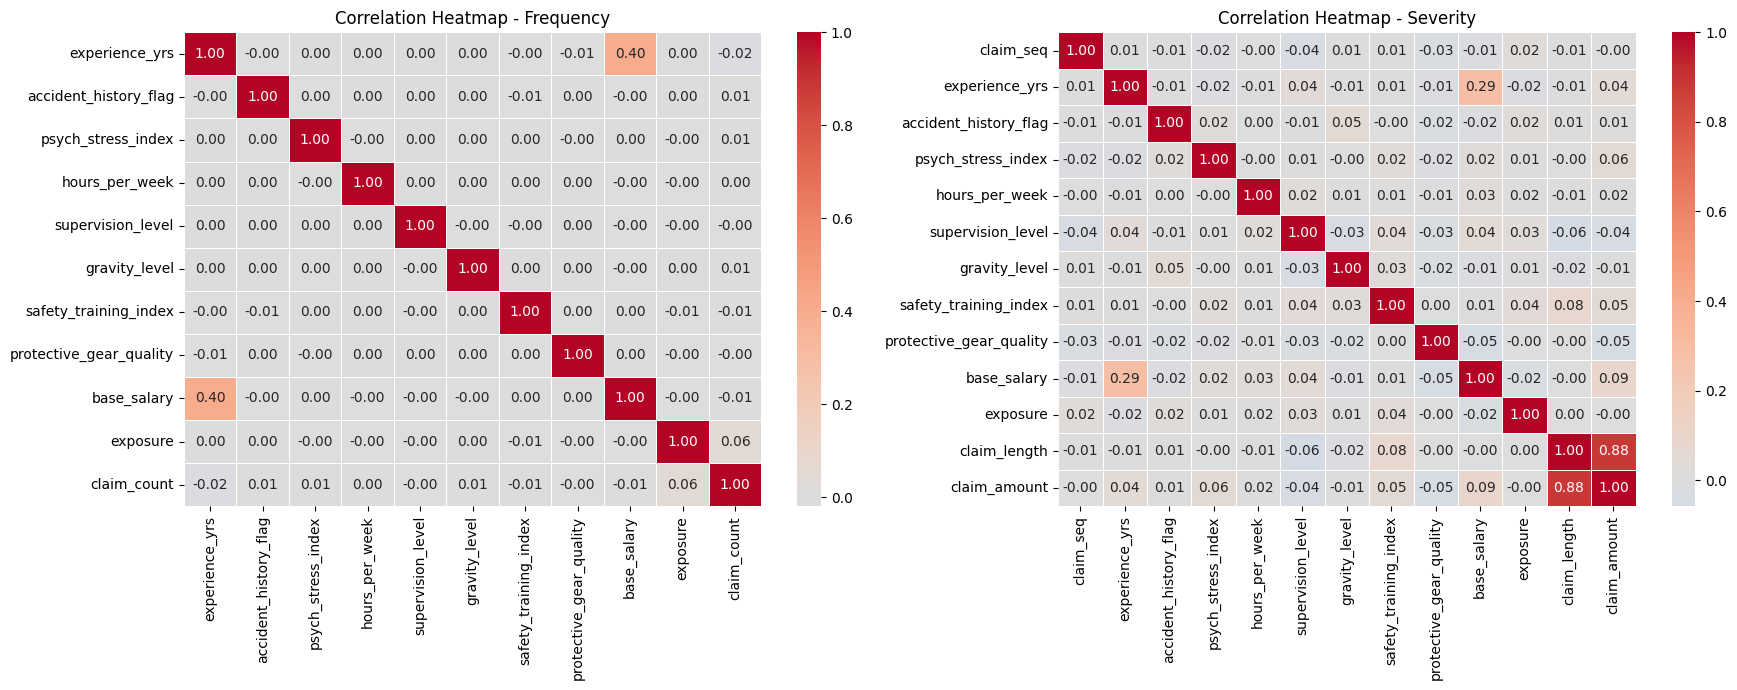

In [13]:
freq_corr = df_workers_freq_filtered.select_dtypes(include="number").corr()
sev_corr = df_workers_sev_filtered.select_dtypes(include="number").corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(freq_corr, ax=axes[0], cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
axes[0].set_title("Correlation Heatmap - Frequency")

sns.heatmap(sev_corr, ax=axes[1], cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
axes[1].set_title("Correlation Heatmap - Severity")

plt.tight_layout()